In [2]:
import pandas as pd
import numpy as np
import nfl_data_py as nfl
import matplotlib.pyplot as plt
import seaborn as sns

# Estructura del Notebook
* §1 · *Data Audit*          → shape, dtypes, missings, coverage temporal
* §2 · *Target Variable*     → home win rate por season/week/roof/surface  

# Data Audit: Shape, dtypes, etc

In [3]:
range_seasons = range(1999, 2026) # 1999-2025 seasons
df = nfl.import_schedules(range_seasons)

In [4]:
shape = df.shape
print(f'Dataframe with {shape[0]:,} rows and {shape[1]} columns')

Dataframe with 7,276 rows and 46 columns


In [5]:
# Know structure of the dataframe
df.head()

,game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,...,wind,away_qb_id,home_qb_id,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium_id,stadium
0,1999_01_MIN_ATL,1999,REG,1,1999-09-12,Sunday,NaN,MIN,17.0,ATL,...,NaN,00-0003761,00-0002876,Randall Cunningham,Chris Chandler,Dennis Green,Dan Reeves,Gerry Austin,ATL00,Georgia Dome
1,1999_01_KC_CHI,1999,REG,1,1999-09-12,Sunday,NaN,KC,17.0,CHI,...,12.0,00-0006300,00-0010560,Elvis Grbac,Shane Matthews,Gunther Cunningham,Dick Jauron,Phil Luckett,CHI98,Soldier Field
2,1999_01_PIT_CLE,1999,REG,1,1999-09-12,Sunday,NaN,PIT,43.0,CLE,...,12.0,00-0015700,00-0004230,Kordell Stewart,Ty Detmer,Bill Cowher,Chris Palmer,Bob McElwee,CLE00,Cleveland Browns Stadium
3,1999_01_OAK_GB,1999,REG,1,1999-09-12,Sunday,NaN,OAK,24.0,GB,...,10.0,00-0005741,00-0005106,Rich Gannon,Brett Favre,Jon Gruden,Ray Rhodes,Tony Corrente,GNB00,Lambeau Field
4,1999_01_BUF_IND,1999,REG,1,1999-09-12,Sunday,NaN,BUF,14.0,IND,...,NaN,00-0005363,00-0010346,Doug Flutie,Peyton Manning,Wade Phillips,Jim Mora,Ron Blum,IND99,RCA Dome


In [6]:
# Columns with NA's
# There are some columns with NA values, some of them we will not use for the model, so it is not a big problem, but it is important to know them.
np.round(df.isna().sum()[df.isna().sum() > 0] / len(df) * 100, 1)

gametime             3.6
nfl_detail_id       96.3
pff                 37.3
ftn                 77.3
away_moneyline      27.2
home_moneyline      27.2
away_spread_odds    27.2
home_spread_odds    27.2
under_odds          27.3
over_odds           27.3
surface              0.6
temp                28.4
wind                28.4
referee              0.0
dtype: float64

In [7]:
# Check if the home_moneyline column has NA values by season, it seems that before 2010 there are a lot of NA values, but after that it seems to be more complete. This is important because we will use as a benchmark with our model.
df.groupby('season')['home_moneyline'].apply(lambda x: x.isna().mean()).round(2)

season
1999    1.00
2000    1.00
2001    1.00
2002    1.00
2003    1.00
2004    1.00
2005    1.00
2006    0.18
2007    0.00
2008    0.27
2009    0.05
2010    0.00
2011    0.00
2012    0.00
2013    0.00
2014    0.00
2015    0.00
2016    0.00
2017    0.00
2018    0.00
2019    0.00
2020    0.00
2021    0.00
2022    0.00
2023    0.00
2024    0.00
2025    0.00
Name: home_moneyline, dtype: float64

In [8]:
t = df.copy().drop(['nfl_detail_id', 'pff', 'ftn', 'away_moneyline', 'away_spread_odds', 'home_spread_odds', 'over_odds', 'under_odds'], axis = 1)
# Create a binary target variable for home team win wich will be our target variable for modeling. It will be 1 if the home team won and 0 otherwise.
t['home_team_win'] = (t['home_score'] > t['away_score']).astype(int)

## Exploratory Analysis: Target Variable 
Understanding Variables

In [9]:
season = t.groupby(['season']).agg({'away_score': 'mean', 'home_score': 'mean', 'home_team_win': 'mean'}).reset_index()
label_size = 9

### Linechart: Home vs Away Score

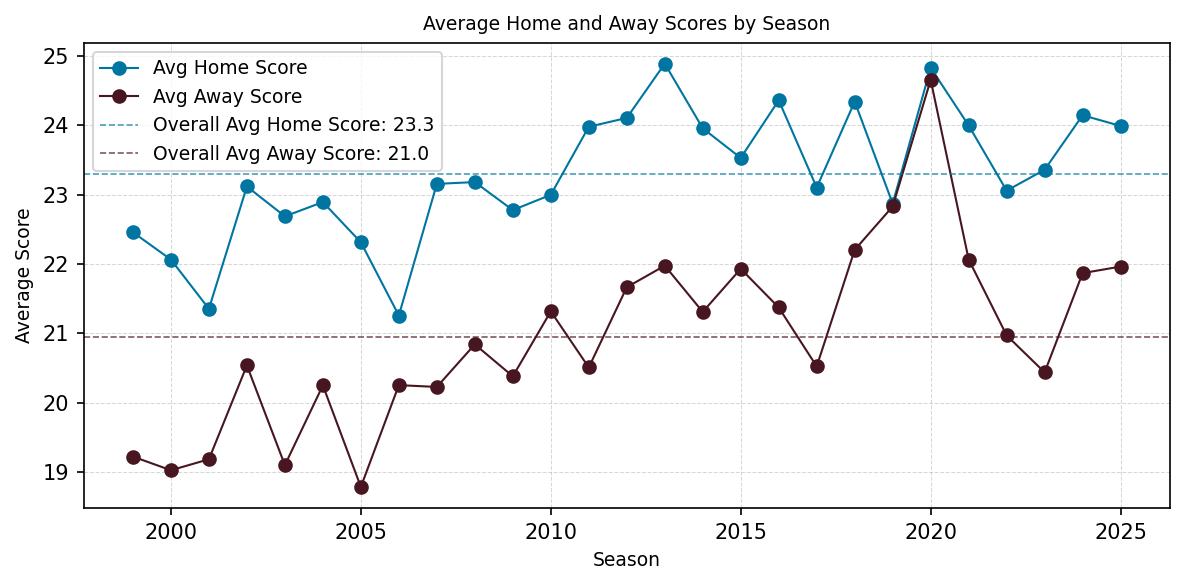

In [10]:

avg_home = t['home_score'].mean()
avg_away = t['away_score'].mean()

# Plot: Comparativa de scores home vs away por temporada, la idea es ver si hay alguna tendencia a lo largo de los años, y también comparar con el promedio general.
# Lo que se observa es que en promedio el equipo local marca 23.3 pts mientras que el equipo visitante marca 21 pts. Esto nos da indicio de que la localía pesa en un partido.
# Adicional, en las temporadas 2019 y 2020 hubo un caso "atípico" ya que los promedios se acercaron bastante.

fig, ax = plt.subplots(figsize = (8, 4), dpi = 150)

plt.plot(season['season'], season['home_score'], marker = 'o', color = '#0075A2', label = 'Avg Home Score', linewidth = 1) 
plt.plot(season['season'], season['away_score'], marker = 'o', color = '#481620', label = 'Avg Away Score', linewidth = 1) #481620

ax.axhline(avg_home, color = '#0075A2', linestyle = '--', alpha = 0.7, label = f'Overall Avg Home Score: {avg_home:.1f}', linewidth = 0.8)
ax.axhline(avg_away, color = '#481620', linestyle = '--', alpha = 0.7, label = f'Overall Avg Away Score: {avg_away:.1f}', linewidth = 0.8)

ax.set_xlabel('Season', fontsize = label_size)
ax.set_ylabel('Average Score', fontsize = label_size)
ax.set_title('Average Home and Away Scores by Season', fontsize = label_size)
ax.legend(fontsize = label_size, loc = 'upper left')
ax.grid(axis = 'both', linestyle = '--', alpha = 0.5, linewidth = 0.5, zorder = -1)
plt.tight_layout()
plt.show()


### Tasa de victorias

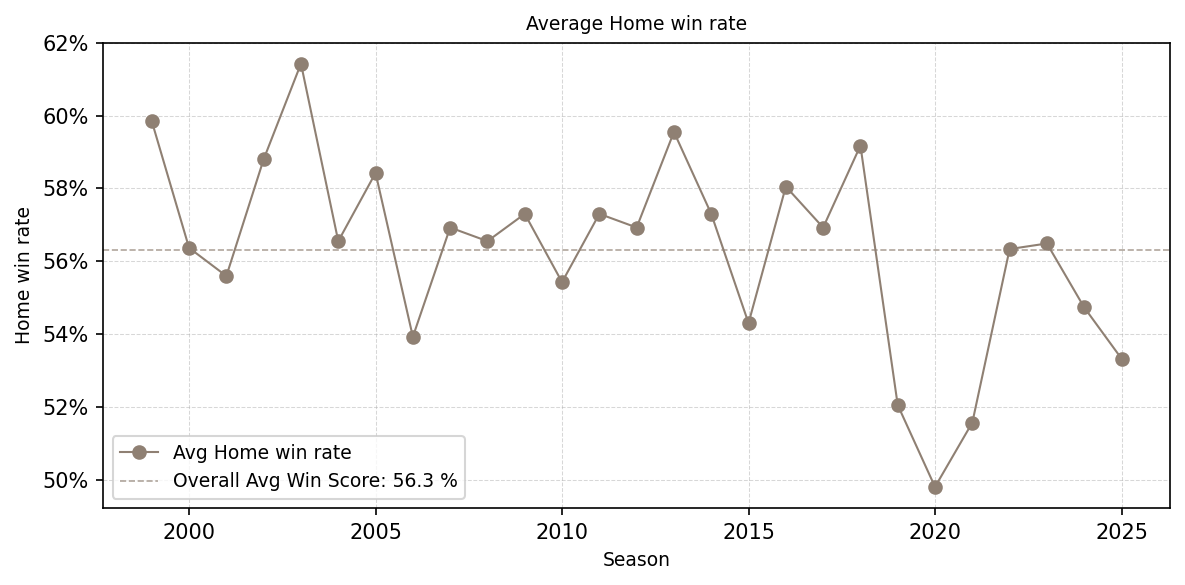

In [11]:

home_win = t['home_team_win'].mean() 

fig, ax = plt.subplots(figsize = (8, 4), dpi = 150)

plt.plot(season['season'], season['home_team_win'], marker = 'o', color = '#8F8073', label = 'Avg Home win rate', linewidth = 1) 
ax.axhline(home_win, color = '#8F8073', linestyle = '--', alpha = 0.7, label = f'Overall Avg Win Score: {home_win*100:.1f} %', linewidth = 0.8)

ax.set_xlabel('Season', fontsize = label_size)
ax.set_ylabel('Home win rate', fontsize = label_size)
ax.set_title('Average Home win rate', fontsize = label_size)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}')) # Formatear el eje y como porcentaje

ax.legend(fontsize = label_size, loc = 'lower left')
ax.grid(axis = 'both', linestyle = '--', alpha = 0.5, linewidth = 0.5, zorder = -1)
plt.tight_layout()
plt.show()

### Home & Away Score por tipo de partido

In [12]:
# El 95% de los partidos son REG: temporada regular, lo cual tiene sentido totalmente. 

# | Partido único de aquí en adelante
# 1.64% Wild Cards 
# 1.48% Divisionales
# 0.74% Conferencia
# 0.37% Super Bowl

# La pregunta importante en esta parte del análisis y saber ¿Qué queremos modelar?
# En primera instancia vamos a modelar la temporada regular, buscamos predecir resultados de partidos de temporada REG.
# Más adelante podríamos modelar los partidos de postemporada, pero por ahora nos enfocaremos en la temporada regular. Es el 95% de los datos con los que contamos.
# Observemos los porcentajes de cada tipo de partido:

t['game_type'].value_counts(normalize = True) * 100

REG    95.753161
WC      1.649258
DIV     1.484332
CON     0.742166
SB      0.371083
Name: game_type, dtype: float64

In [13]:
# Se observa una diferencia en la tasa de victoria del equipo local entre tipo de partido 
# REG se mantiene constante con el 56% que veíamos antes. 
# En partidos de eliminación (post temporada) comienza a haber un cambio, los WC tienen una tasa de victoria del equipo local del 58% en promedio. 
# Los partidos divisionales tienen un 69% 
# Los partidos de CON tienen un 66%
# Los partidos de SB es el caso más atípico, con un 37% aunque aquí tenemos muchos ceros, esto mueve el promedio.

wrst = t.groupby(['season', 'game_type'])['home_team_win'].mean().unstack()
wrst.mean()

game_type
CON    0.666667
DIV    0.694444
REG    0.560767
SB     0.370370
WC     0.586420
dtype: float64

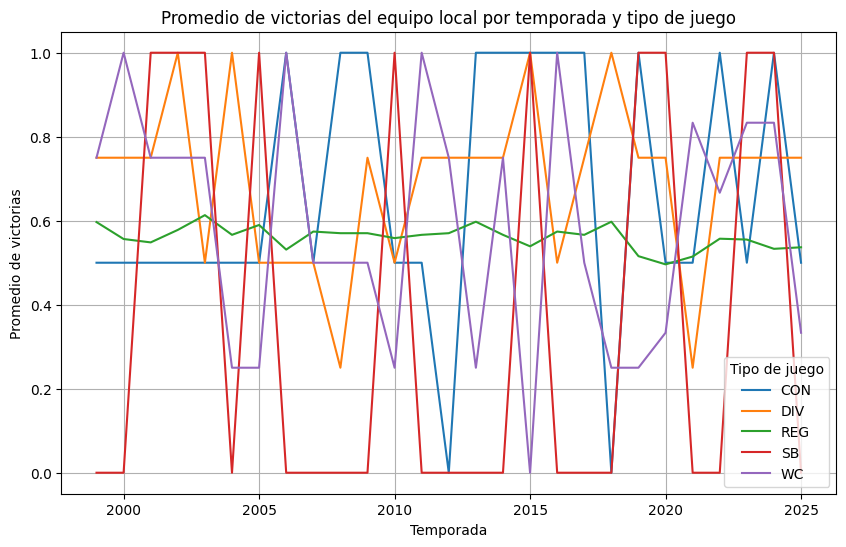

In [14]:
import matplotlib.pyplot as plt

# Excluir la columna 'SB' del DataFrame
wrst_filtered = wrst.drop(columns=[''], errors='ignore')

# Crear el gráfico de líneas
wrst_filtered.plot(kind='line', figsize=(10, 6))

# Configurar etiquetas y título
plt.title('Promedio de victorias del equipo local por temporada y tipo de juego')
plt.xlabel('Temporada')
plt.ylabel('Promedio de victorias')
plt.legend(title='Tipo de juego')
plt.grid(True)

# Mostrar el gráfico
plt.show()

In [15]:
t

,game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,...,away_qb_id,home_qb_id,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium_id,stadium,home_team_win
0,1999_01_MIN_ATL,1999,REG,1,1999-09-12,Sunday,NaN,MIN,17.0,ATL,...,00-0003761,00-0002876,Randall Cunningham,Chris Chandler,Dennis Green,Dan Reeves,Gerry Austin,ATL00,Georgia Dome,0
1,1999_01_KC_CHI,1999,REG,1,1999-09-12,Sunday,NaN,KC,17.0,CHI,...,00-0006300,00-0010560,Elvis Grbac,Shane Matthews,Gunther Cunningham,Dick Jauron,Phil Luckett,CHI98,Soldier Field,1
2,1999_01_PIT_CLE,1999,REG,1,1999-09-12,Sunday,NaN,PIT,43.0,CLE,...,00-0015700,00-0004230,Kordell Stewart,Ty Detmer,Bill Cowher,Chris Palmer,Bob McElwee,CLE00,Cleveland Browns Stadium,0
3,1999_01_OAK_GB,1999,REG,1,1999-09-12,Sunday,NaN,OAK,24.0,GB,...,00-0005741,00-0005106,Rich Gannon,Brett Favre,Jon Gruden,Ray Rhodes,Tony Corrente,GNB00,Lambeau Field,1
4,1999_01_BUF_IND,1999,REG,1,1999-09-12,Sunday,NaN,BUF,14.0,IND,...,00-0005363,00-0010346,Doug Flutie,Peyton Manning,Wade Phillips,Jim Mora,Ron Blum,IND99,RCA Dome,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7271,2025_20_HOU_NE,2025,DIV,20,2026-01-18,Sunday,15:00,HOU,16.0,NE,...,00-0039163,00-0039851,C.J. Stroud,Drake Maye,DeMeco Ryans,Mike Vrabel,Shawn Smith,BOS00,Gillette Stadium,1
7272,2025_20_LA_CHI,2025,DIV,20,2026-01-18,Sunday,18:30,LA,20.0,CHI,...,00-0026498,00-0039918,Matthew Stafford,Caleb Williams,Sean McVay,Ben Johnson,Shawn Hochuli,CHI98,Soldier Field,0
7273,2025_21_NE_DEN,2025,CON,21,2026-01-25,Sunday,15:00,NE,10.0,DEN,...,00-0039851,00-0035264,Drake Maye,Jarrett Stidham,Mike Vrabel,Sean Payton,Alex Kemp,DEN00,Empower Field at Mile High,0
7274,2025_21_LA_SEA,2025,CON,21,2026-01-25,Sunday,18:30,LA,27.0,SEA,...,00-0026498,00-0034869,Matthew Stafford,Sam Darnold,Sean McVay,Mike Macdonald,Clay Martin,SEA00,Lumen Field,1


In [19]:
# § Calibración de HOME_ADVANTAGE
# Si ambos equipos tienen el mismo ELO, el único factor
# que diferencia local de visitante es HOME_ADVANTAGE.
# Queremos que el sistema reproduzca el home win rate observado.
#
# P_home = 1 / (1 + 10^(-HA/400)) = observed_rate
# Despejando HA:
# HA = -400 × log10((1/observed_rate) - 1)


# observed_home_win_rate using all seasons
observed_home_win_rate = t.query("game_type == 'REG'")['home_team_win'].mean() 
HOME_ADVANTAGE = -400 * np.log10((1 / observed_home_win_rate) - 1)

print(f"Home win rate observado : {observed_home_win_rate:.4f}")
print(f"HOME_ADVANTAGE calibrado: {HOME_ADVANTAGE:.1f} puntos ELO")

Home win rate observado : 0.5605
HOME_ADVANTAGE calibrado: 42.2 puntos ELO


### Semanas de juego x Temporada

In [42]:
# t = t.query("game_type == 'REG'").copy()

# Weeks x Season: En 2021 se agregó un partido más a la temporada regular, pasando de 17 partidos a 18 partidos por equipo. 
# Esto se traduce en un aumento de semanas de temporada regular. Mayor desgaste para algunos equipos (previo a juegos post temporada).
# Algunos equipos aprovechan para dar descanso a algunos jugadores en la última semana, lo que puede afectar el resultado de ese partido. 

wxs = t.groupby(['season'])['week'].nunique()

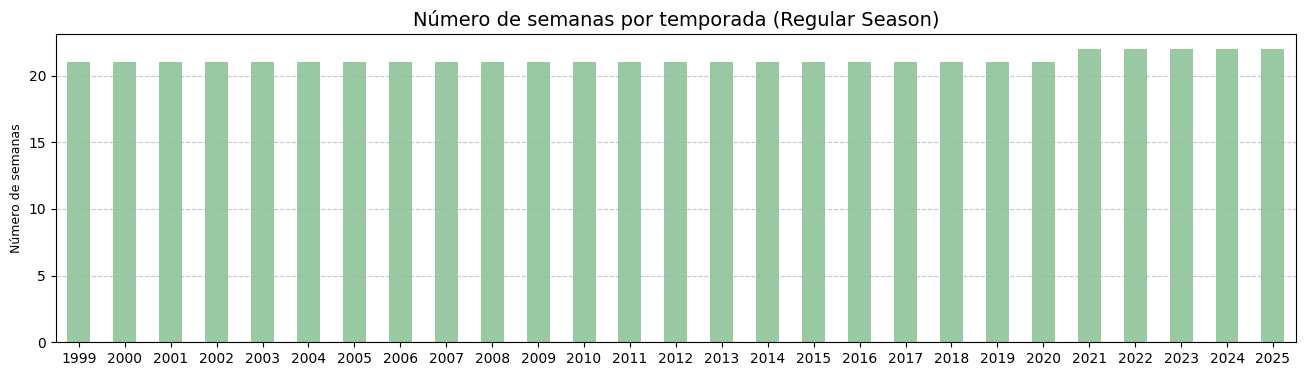

In [43]:
# Crear el gráfico de barras
wxs.plot(kind='bar', figsize=(16, 4), color='#98C9A3')

# Configurar etiquetas y título
plt.title('Número de semanas por temporada (Regular Season)', fontsize=14)
plt.xlabel('', fontsize=label_size)
plt.ylabel('Número de semanas', fontsize=label_size)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.show()

### Número de juegos por temporada

Existen dos observaciones importantes para esta parte:
1. Temporada 2002: Se agregó la franquicia de los Houston Texans pasando de 31 a 32 equipos y pasando de 248 a 256 juegos por temporada. 
2. Temporada de 2021: Se agregó una semana adicional, por lo que cada equipo juega un partido adicional, pasando de 256 a 272 partidos por temporada. 

Obs: en 2022 se tuvieron 271 juegos, investigando encontré que en ese año se canceló el juego Bills vs Bengals esto debido a que Damar Hamlin, safety de los Buffalo Bills, sufrió un paro cardíaco el 2 de enero de 2023 tras un choque directo en el pecho durante un partido de la NFL.

In [44]:
season = t.groupby(['season'], as_index= False).agg({'game_id': 'nunique', 'home_team': 'nunique'})

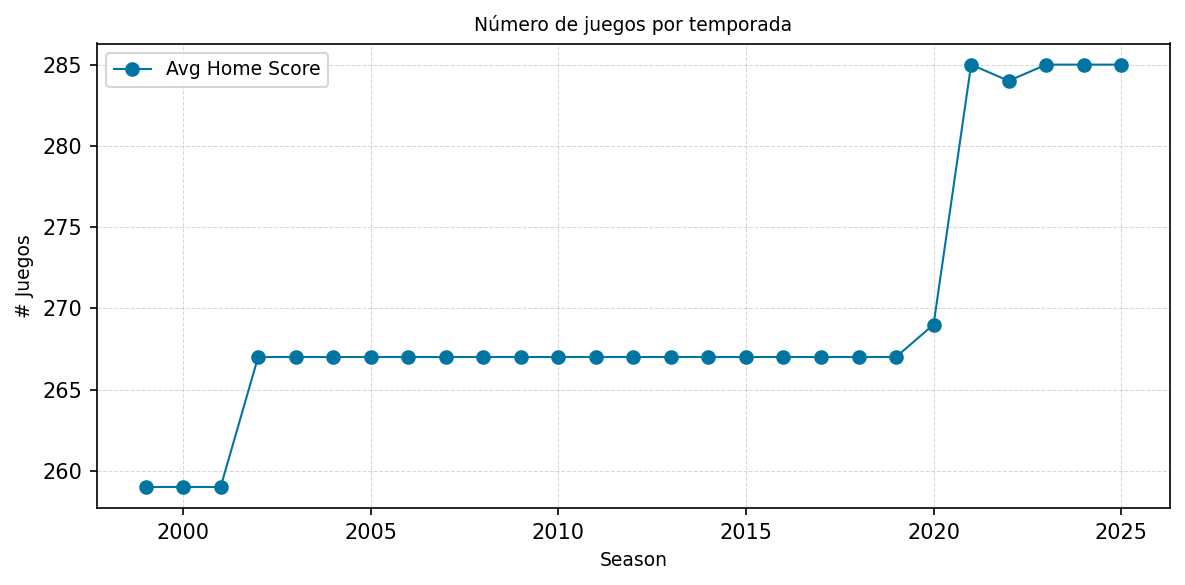

In [46]:
# Fig: Número de partidos
fig, ax = plt.subplots(figsize = (8, 4), dpi = 150)

plt.plot(season['season'], season['game_id'], marker = 'o', color = '#0075A2', label = 'Avg Home Score', linewidth = 1) 

ax.set_xlabel('Season', fontsize = label_size)
ax.set_ylabel('# Juegos', fontsize = label_size)
ax.set_title('Número de juegos por temporada', fontsize = label_size)
ax.legend(fontsize = label_size, loc = 'upper left')
ax.grid(axis = 'both', linestyle = '--', alpha = 0.5, linewidth = 0.5, zorder = -1)
plt.tight_layout()
plt.show()

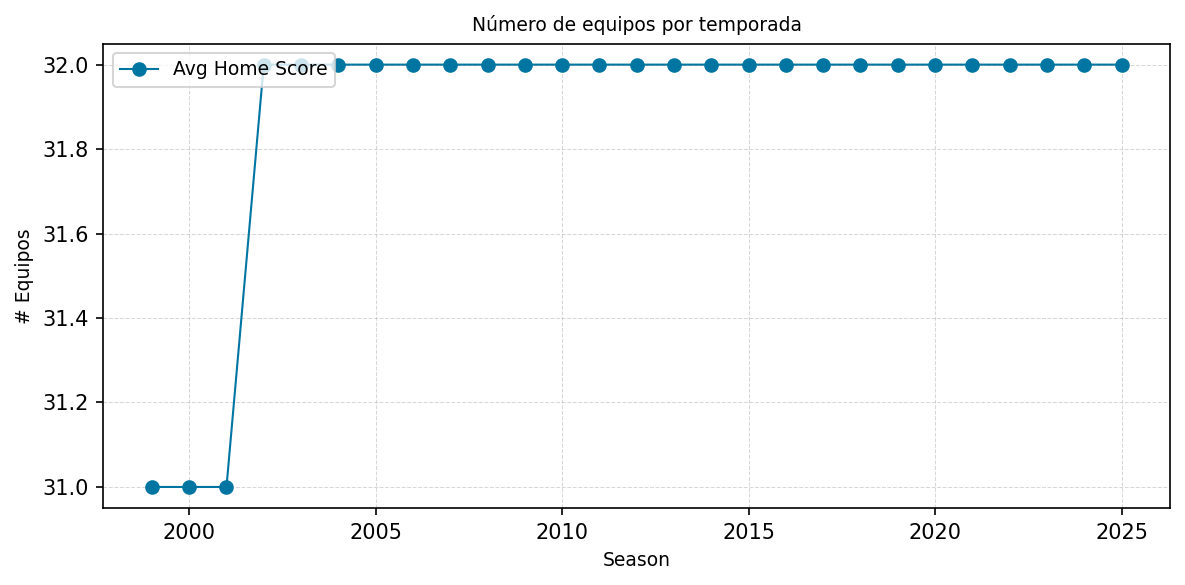

In [47]:
# Fig
fig, ax = plt.subplots(figsize = (8, 4), dpi = 150)

plt.plot(season['season'], season['home_team'], marker = 'o', color = '#0075A2', label = 'Avg Home Score', linewidth = 1) 

ax.set_xlabel('Season', fontsize = label_size)
ax.set_ylabel('# Equipos', fontsize = label_size)
ax.set_title('Número de equipos por temporada', fontsize = label_size)
ax.legend(fontsize = label_size, loc = 'upper left')
ax.grid(axis = 'both', linestyle = '--', alpha = 0.5, linewidth = 0.5, zorder = -1)
plt.tight_layout()
plt.show()

### Heatmap: Partidos por día de la semana y hora

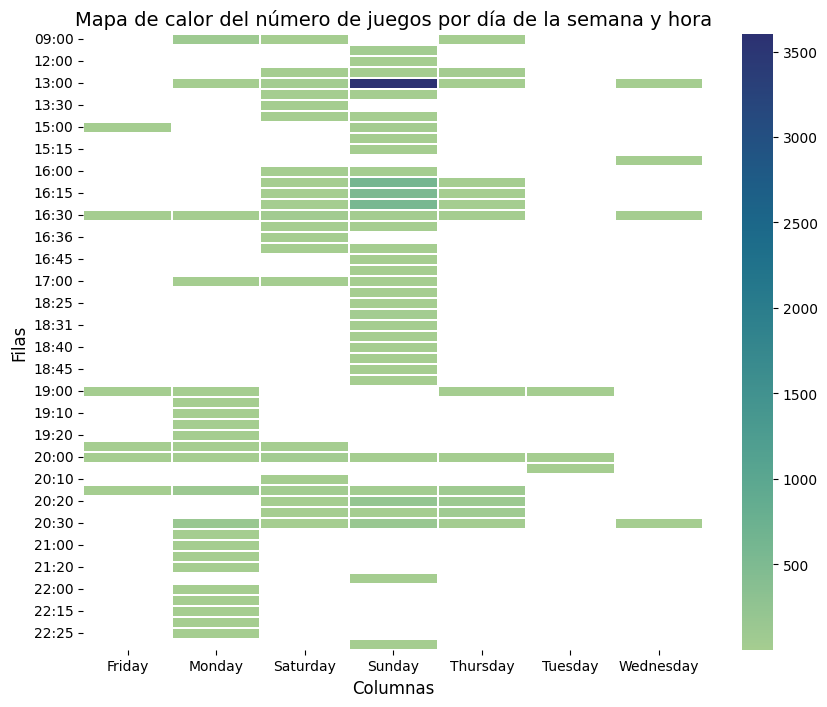

In [48]:
pivot = t.pivot_table(index = 'gametime', columns = 'weekday', values = 'game_id', aggfunc = 'count')

# Crear el heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(pivot, annot=False, fmt=",0", cmap="crest", cbar=True, linewidth = 0.01)

# Configurar etiquetas y título
plt.title('Mapa de calor del número de juegos por día de la semana y hora', fontsize=14)
plt.xlabel('Columnas', fontsize=12)
plt.ylabel('Filas', fontsize=12)

# Mostrar el gráfico
plt.show()

# La gran mayoría de juegos son los domingos a las 13:00 hrs

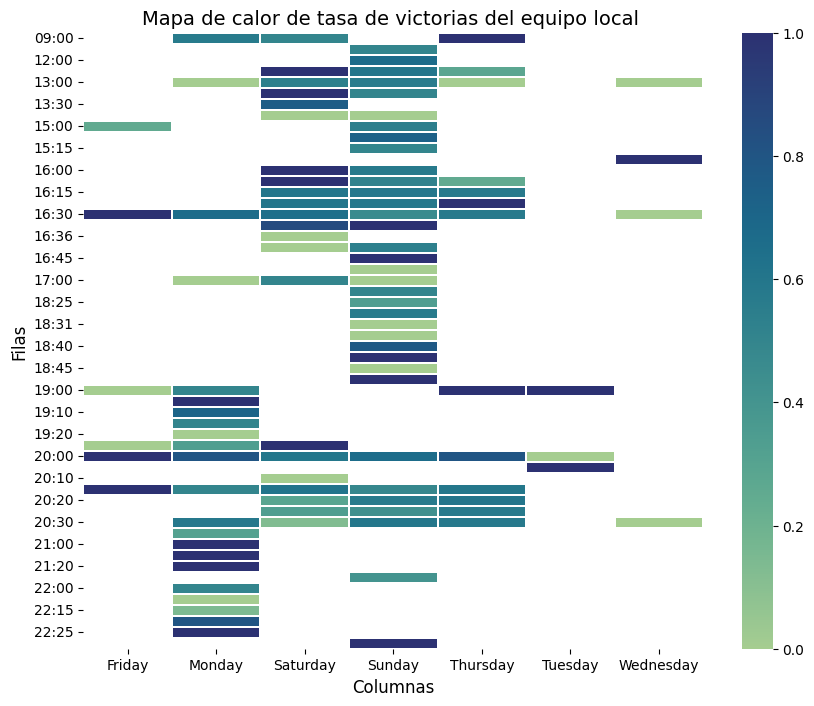

In [49]:
pivot = t.pivot_table(index = 'gametime', columns = 'weekday', values = 'home_team_win', aggfunc = 'mean')

# Crear el heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(pivot, annot=False, fmt=",0", cmap="crest", cbar=True, linewidth = 0.01)

# Configurar etiquetas y título
plt.title('Mapa de calor de tasa de victorias del equipo local ', fontsize=14)
plt.xlabel('Columnas', fontsize=12)
plt.ylabel('Filas', fontsize=12)

# Mostrar el gráfico
plt.show()


In [50]:
## Hay muy pocos juegos en Viernes, martes y miércoles, por lo que los vería como "días atípicos".
# La mayoría está en domingo, depués sigue el lunes, jueves y sábado. 

# Considero que podríamos prescindir de juegos de días como viernes, martes y miércoles ya que no aportan mucha información. Son cerca de 19 juegos = 0.27% de los juegos
# Hay una ligera mejora en la tasa de victorias del equipo local por día de la semana, veamos así: 

# Lunes: 54%
# Jueves: 57%
# Sábado: 60%
# Domingo: 56%

weekday = t.groupby(['weekday']).agg({'home_team_win': 'mean', 'game_id': 'count'}).reset_index()
weekday

,weekday,home_team_win,game_id
0,Friday,0.500000,10
1,Monday,0.541667,480
2,Saturday,0.603113,257
3,Sunday,0.562591,6191
4,Thursday,0.574468,329
5,Tuesday,0.800000,5
6,Wednesday,0.250000,4


Veamos si el número de días ha cambiado por temporada, puede que la estructura sea diferente

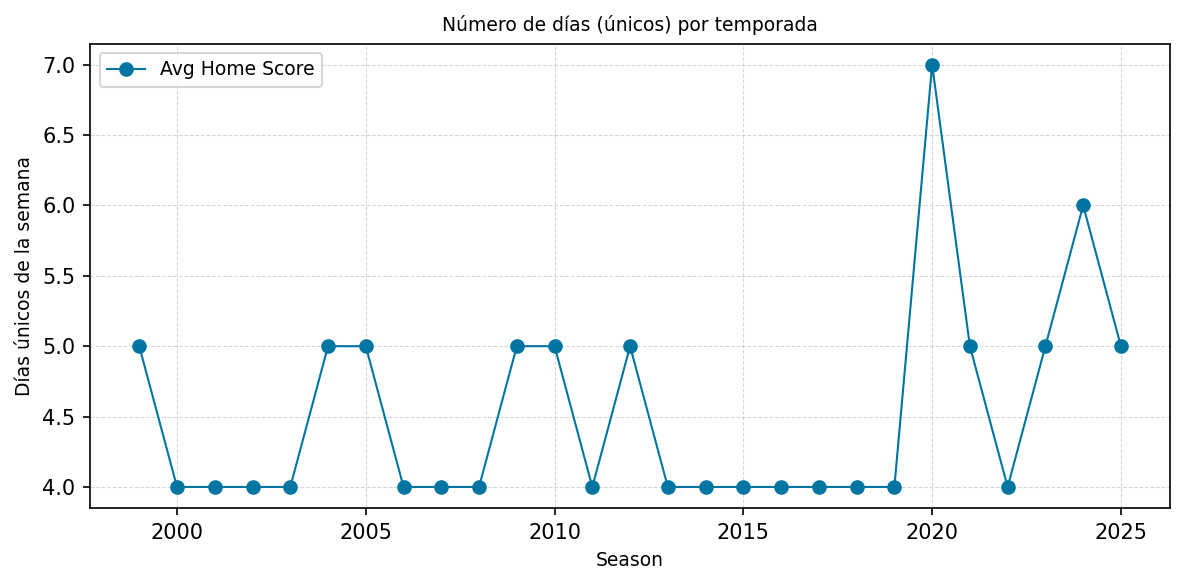

In [51]:
season = t.groupby(['season'])['weekday'].nunique().reset_index()

fig, ax = plt.subplots(figsize = (8, 4), dpi = 150)

plt.plot(season['season'], season['weekday'], marker = 'o', color = '#0075A2', label = 'Avg Home Score', linewidth = 1) 

ax.set_xlabel('Season', fontsize = label_size)
ax.set_ylabel('Días únicos de la semana', fontsize = label_size)
ax.set_title('Número de días (únicos) por temporada', fontsize = label_size)
ax.legend(fontsize = label_size, loc = 'upper left')
ax.grid(axis = 'both', linestyle = '--', alpha = 0.5, linewidth = 0.5, zorder = -1)
plt.tight_layout()
plt.show()

# Tenemos un pico en temporada 2020, lo cual debe estar relacionado con la pandemia. 

In [52]:
print('Comparativo de tasa de victorias pre, durante y post pandemia')
t['PANDEMIC_SITUATION'] = -1
t.loc[t['season'] == 2020, 'PANDEMIC_SITUATION'] = 0
t.loc[t['season'] > 2020, 'PANDEMIC_SITUATION'] = 1

Comparativo de tasa de victorias pre, durante y post pandemia


In [53]:
agg = t.groupby(['weekday', 'PANDEMIC_SITUATION']).agg({'home_team_win': 'mean', 'game_id': 'count'}).reset_index()
agg['size_pct'] = (agg['game_id'] / agg['game_id'].sum() ) * 100
agg

,weekday,PANDEMIC_SITUATION,home_team_win,game_id,size_pct
0,Friday,-1,0.250000,4,0.054975
1,Friday,0,1.000000,1,0.013744
2,Friday,1,0.600000,5,0.068719
3,Monday,-1,0.556180,356,4.892798
4,Monday,0,0.300000,20,0.274876
5,Monday,1,0.538462,104,1.429357
6,Saturday,-1,0.594595,185,2.542606
7,Saturday,0,0.400000,10,0.137438
8,Saturday,1,0.661290,62,0.852117
9,Sunday,-1,0.570687,4817,66.203958


In [54]:
t.groupby(['PANDEMIC_SITUATION']).agg({'home_team_win': 'mean', 'game_id': 'count'}).reset_index()

,PANDEMIC_SITUATION,home_team_win,game_id
0,-1,0.570840,5583
1,0,0.498141,269
2,1,0.544944,1424


In [55]:
pd.pivot_table(data = t, index = 'weekday', columns = 'PANDEMIC_SITUATION', values = 'home_team_win', aggfunc = 'mean')

PANDEMIC_SITUATION,-1,0,1
weekday,,,
Friday,0.250000,1.000000,0.600000
Monday,0.556180,0.300000,0.538462
Saturday,0.594595,0.400000,0.661290
Sunday,0.570687,0.515837,0.537728
Thursday,0.589041,0.428571,0.562500
Tuesday,0.000000,1.000000,1.000000
Wednesday,0.000000,1.000000,0.000000


### Histogramas

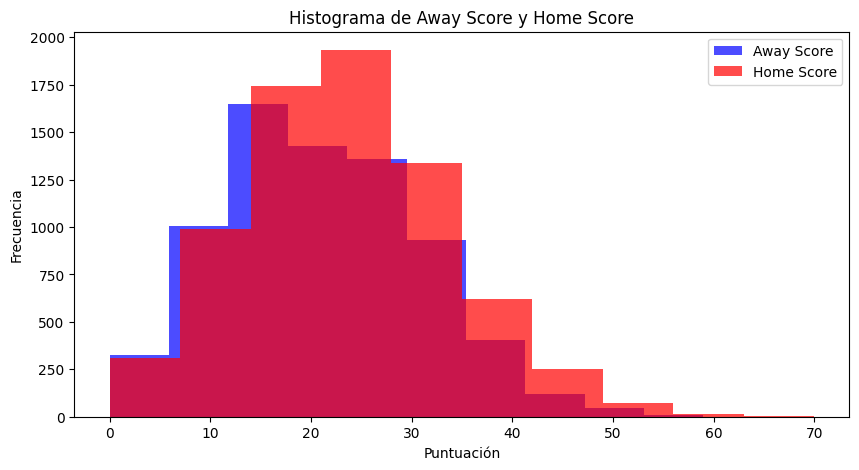

In [56]:
# Histograma para 'away_score'
plt.figure(figsize=(10, 5))
plt.hist(t['away_score'], bins=10, alpha=0.7, color='blue', label='Away Score')
plt.hist(t['home_score'], bins=10, alpha=0.7, color='red', label='Home Score')
plt.title('Histograma de Away Score y Home Score')
plt.xlabel('Puntuación')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

<BarContainer object of 32 artists>

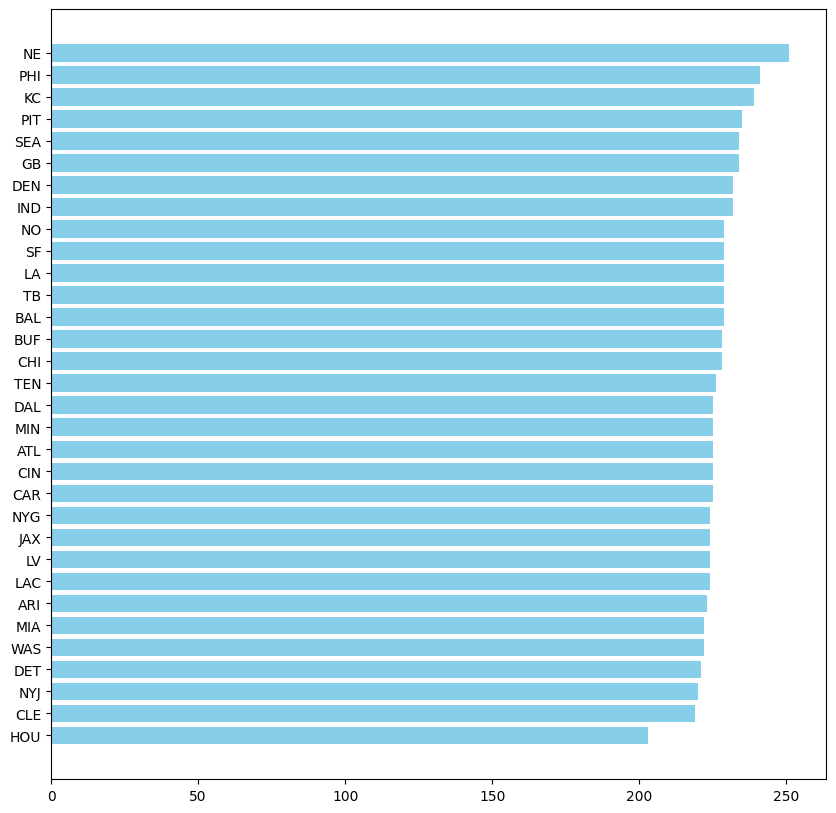

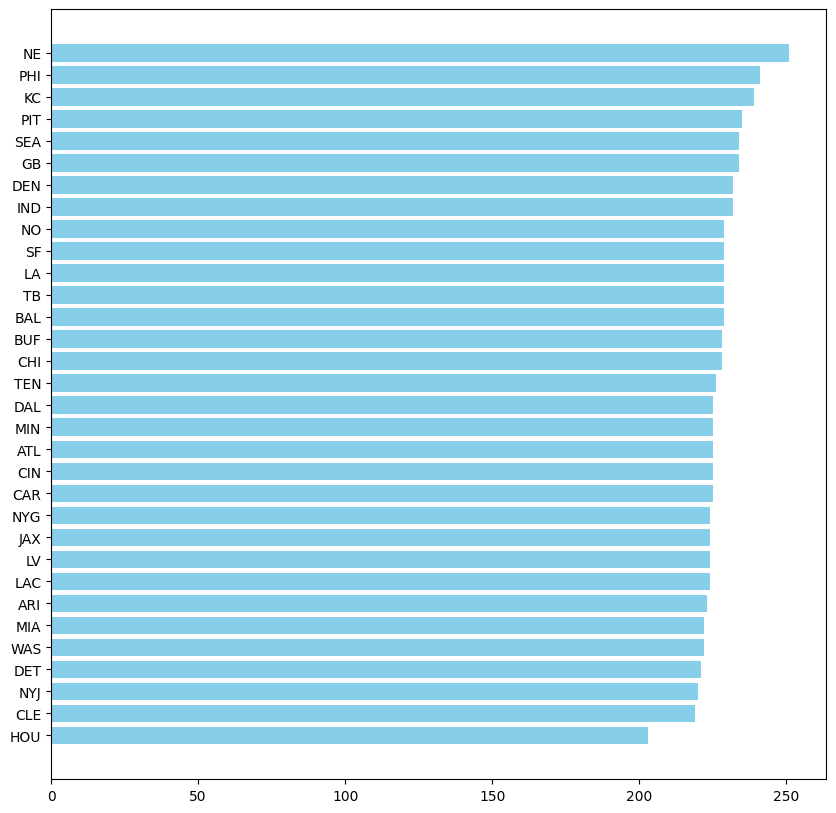

In [57]:
teams_labels = t['home_team'].value_counts().sort_values()

plt.figure(figsize=(10, 10))
plt.barh(teams_labels.index, teams_labels.values, color='skyblue')

# Hay un par de franquicias que han cambiado de "etiqueta"
# Observando la gráfica se observa que hay equipos "con más juegos"
# El único equipo con menor juegos debería ser HOU porque se creó después de 1999
# Las etiquetas: OAK, SD, STL, LA, LAC y LV son etiquetas que han sido utilizadas por diferentes franquicias a lo largo del tiempo, lo que puede generar confusión al analizar los datos.
# Vamos a "homologarlas"

franchise_map = {
    # Rams
    "STL": "LA",
    "LA": "LA",
    "LAR": "LA",

    # Raiders
    "OAK": "LV",
    "LV": "LV",
    "LVR": "LV",

    # Chargers
    "SD": "LAC",
    "LAC": "LAC"
}

t["home_team"] = t["home_team"].replace(franchise_map)
t["away_team"] = t["away_team"].replace(franchise_map)

teams_labels = t['home_team'].value_counts().sort_values()

plt.figure(figsize=(10, 10))
plt.barh(teams_labels.index, teams_labels.values, color='skyblue')

---

## § Resumen de hallazgos · EDA

### Dataset
- **7,276 registros × 46 columnas** · Temporadas 1999–2025
- **Variable objetivo:** `home_team_win = (home_score > away_score).astype(int)`

### Estructura temporal
| Evento | Temporada | Impacto |
|---|---|---|
| Expansión Houston Texans | 2002 | 31 → 32 equipos · 248 → 256 juegos/temporada |
| Temporada COVID | 2020 | Sin aficionados · home win rate cae a ~49% |
| Temporada de 17 juegos | 2021 | 256 → 272 juegos/temporada |
| Cancelación Bills vs Bengals | 2022 | 271 juegos (Damar Hamlin) |

### Datos faltantes relevantes
| Columna | % Missing | Causa |
|---|---|---|
| `home_moneyline` / `away_moneyline` | 27.2% | Concentrado en 1999–2005 |
| `temp` / `wind` | 28.4% | Juegos en domo + histórico incompleto |
| `nfl_detail_id` | 96.3% | No se utiliza |

→ El benchmark de Vegas aplica limpio a **2007–2025** (~4,500 juegos)

### Variable objetivo
- **Home win rate global: 56.3%** (promedio 1999–2025)
- Tendencia: declinante post-2020, era 2021–2025 promedia ~53–54%
- **2020 es un outlier estructural** (COVID, sin fans): home win rate ~49%

### Home win rate por tipo de partido
| game_type | Home Win Rate | N juegos/temporada |
|---|---|---|
| REG | 56.1% | ~272 |
| WC | 58.6% | 6 |
| DIV | 69.4% | 4 |
| CON | 66.7% | 2 |
| SB | 37.0% | 1 (cancha neutral) |

### Home win rate por día de la semana
| Día | Home Win Rate | Observación |
|---|---|---|
| Domingo | 56% | Día principal (~57% de juegos) |
| Jueves | 57% | Thursday Night Football |
| Lunes | 54% | Monday Night Football |
| Sábado | 51% | Late season · posible rotación de titulares |
| Vie/Mar/Mié | — | 19 juegos en 26 años · excluir |

### Franquicias reubicadas (relevante para ELO)
| Abreviatura histórica | Abreviatura actual | Año de cambio |
|---|---|---|
| OAK | LV | 2020 |
| SD | LAC | 2017 |
| STL | LA | 2016 |

---

## § Decision Log · Parámetros y decisiones de diseño

Este log documenta todas las decisiones tomadas durante el EDA
que afectan el diseño de las fases siguientes.
Cada decisión incluye la justificación numérica.

---

### ELO System (Notebook 02)

| Parámetro | Valor | Justificación |
|---|---|---|
| `ELO_INICIAL` | 1500 | Convención estándar |
| `HOME_ADVANTAGE` | **44** | Calibrado desde home win rate observado 56.3%: `HA = -400 × log10((1/0.563) - 1) ≈ 44` |
| `HOME_ADVANTAGE` Super Bowl | **0** | Cancha neutral · home win rate SB = 37% es ruido sobre 26 juegos |
| `K_REGULAR` | **20** | FiveThirtyEight (2014) · validar con backtesting en Fase 2 |
| `K_PLAYOFFS` | **24** | K × 1.2 · mayor peso informativo por partido eliminatorio |
| `REGRESION_MEDIA` | 0.33 | FiveThirtyEight · equivalente a `ELO_inicio = 0.67 × ELO_final + 0.33 × 1505` |
| `MEDIA_GLOBAL` | 1505 | Media empírica de la NFL |
| Scope de actualización ELO | **Todos los game_types** | REG + WC + DIV + CON + SB · maximiza información entre temporadas |
| Normalización abreviaturas | OAK→LV, SD→LAC, STL→LA | ELO continuo requiere franquicia única a lo largo del tiempo |

> **Nota HOME_ADVANTAGE:** FiveThirtyEight usa HA=65, calibrado sobre era 1990–2015
> cuando home win rate era ~58%. Nuestros datos 1999–2025 tienen 56.3% → HA=44.
> La era 2021–2025 sugiere HA≈34. Validar con backtesting si HA constante
> o era-based mejora el Brier Score.

---

### Feature Engineering (Notebook 03)

| Feature | Decisión | Justificación |
|---|---|---|
| `elo_diff` | ✅ Feature principal | `R_home - R_away + HA` · captura ~85-90% del poder predictivo |
| `home_rest` | ✅ Feature | Días de descanso local · efecto marginal pero medible |
| `away_rest` | ✅ Feature | Días de descanso visitante |
| `div_game` | ✅ Feature | Rivalidades divisionales tienen dinámica propia |
| `week` | ✅ Normalizado | `week_norm = week / max_week_season` · resuelve transición 16→17 juegos en 2021 |
| `home_moneyline` | ❌ Nunca feature | Solo benchmark externo (Brier Score) · incluirlo sería circular |
| `PANDEMIC_SITUATION` | ❌ No es feature | Constante en inferencia 2026 · usar como `sample_weight` para down-weightear 2020 |
| `qb_name` | ❌ No es feature | El ELO lo captura indirectamente vía resultados |
| Días Vie/Mar/Mié | ❌ Excluir | 19 juegos en 26 años (0.27%) · sin poder estadístico |

---

### Validación y Benchmark (Notebook 03)

| Decisión | Valor |
|---|---|
| Benchmark externo | Vegas moneylines convertidas a probabilidad (vig removido) |
| Período válido del benchmark | 2007–2025 (missings concentrados en 1999–2005) |
| Métricas de evaluación | Brier Score · Log-Loss · Accuracy · Calibration Curve |
| Estrategia de validación | Ventana expandible: train 1999–2021 → test 2022–2024 |
| Down-weight COVID | `sample_weight`: 2020 = 0.3 · resto = 1.0 |

---

### Scope del modelo predictivo (Notebook 03–04)

| Decisión | Valor |
|---|---|
| Entrenamiento | Juegos REG únicamente |
| Predicción 2026 | Juegos REG de temporada regular |
| Coeficientes β | Fijos (calculados una vez sobre 1999–2025) |
| ELO durante 2026 | Actualización dinámica partido a partido |

---

*Última actualización: Fase 1 completa · Siguiente: implementar `elo.py` (Notebook 02)*